# Conda Environment: nichebreadth

---

# Library imports

In [1]:
# import OS for shell functionality
import os

# for python data manipulation and plotting
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# for KDE estimation
import statsmodels.api as sm

# for running R through Python
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

# Load the rpy2 extension
%load_ext rpy2.ipython

## R library imports
# for handling data
importr('dplyr')

# for calculating niche breadths
importr('MicroNiche')     # NOTE: installed via R, not Conda.

# for testing data modality
importr('LaplacesDemon')

# for finding antimodes
importr('multimode');

---

# Create Output Directories

In [2]:
!mkdir -p ../Datasets/Niche_breadth
!mkdir -p ../Figures/Niche_breadth

---

# Import Data

#### Sample metadata

In [3]:
sample_data = pd.read_csv("../Datasets/sample-data.csv")

---

# Calculate Levin's Niche Breadth

In [4]:
%%R

# Read in absolute abundance sequence tables
s1_active_absolute = read.csv("../Datasets/Absolute_abundance/StageOneActive_AA.csv")

# Create sample information variable for MicroNiche levins.Bn
sample_info = c(rep('5',3),rep('10',3),rep('15',3),rep('20',3),rep('25',3),rep('30',3),rep('35',3),rep('40',3),rep('45',3))

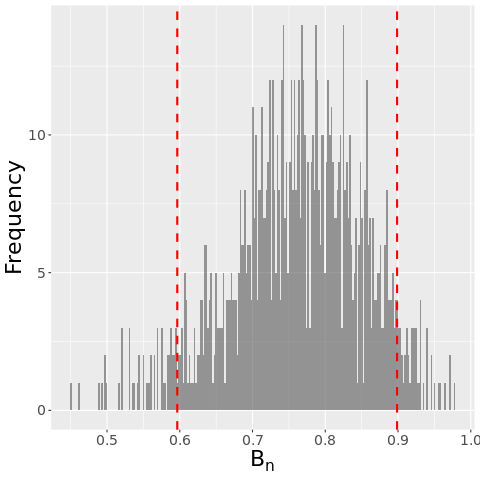

In [5]:
%%R

# Calculate Levin's niche breadth
niche_breadth = levins.Bn(s1_active_absolute, 9, sample_info)
write.csv(niche_breadth,"../Datasets/Niche_breadth/StageOneActive_NicheBreadth.csv")

---

# Inspect Niche Breadth Data

**Import and Process**

In [6]:
# Import data and rename ASV_ID column
niche_breadth = pd.read_csv("../Datasets/Niche_breadth/StageOneActive_NicheBreadth.csv")
niche_breadth.rename(columns= {'Unnamed: 0': 'ASV_ID'}, inplace= True)

# Subset above LOQ
niche_breadth = niche_breadth[niche_breadth["Below.LOQ"] == "N"]

**Calculate location of modes for Levin's niche breadth**

In [7]:
%%R

niche_breadth = niche_breadth %>% filter(Below.LOQ == 'N')
modes = Modes(niche_breadth$Bn)$modes

**Plot Distribution of Niche Breadths**

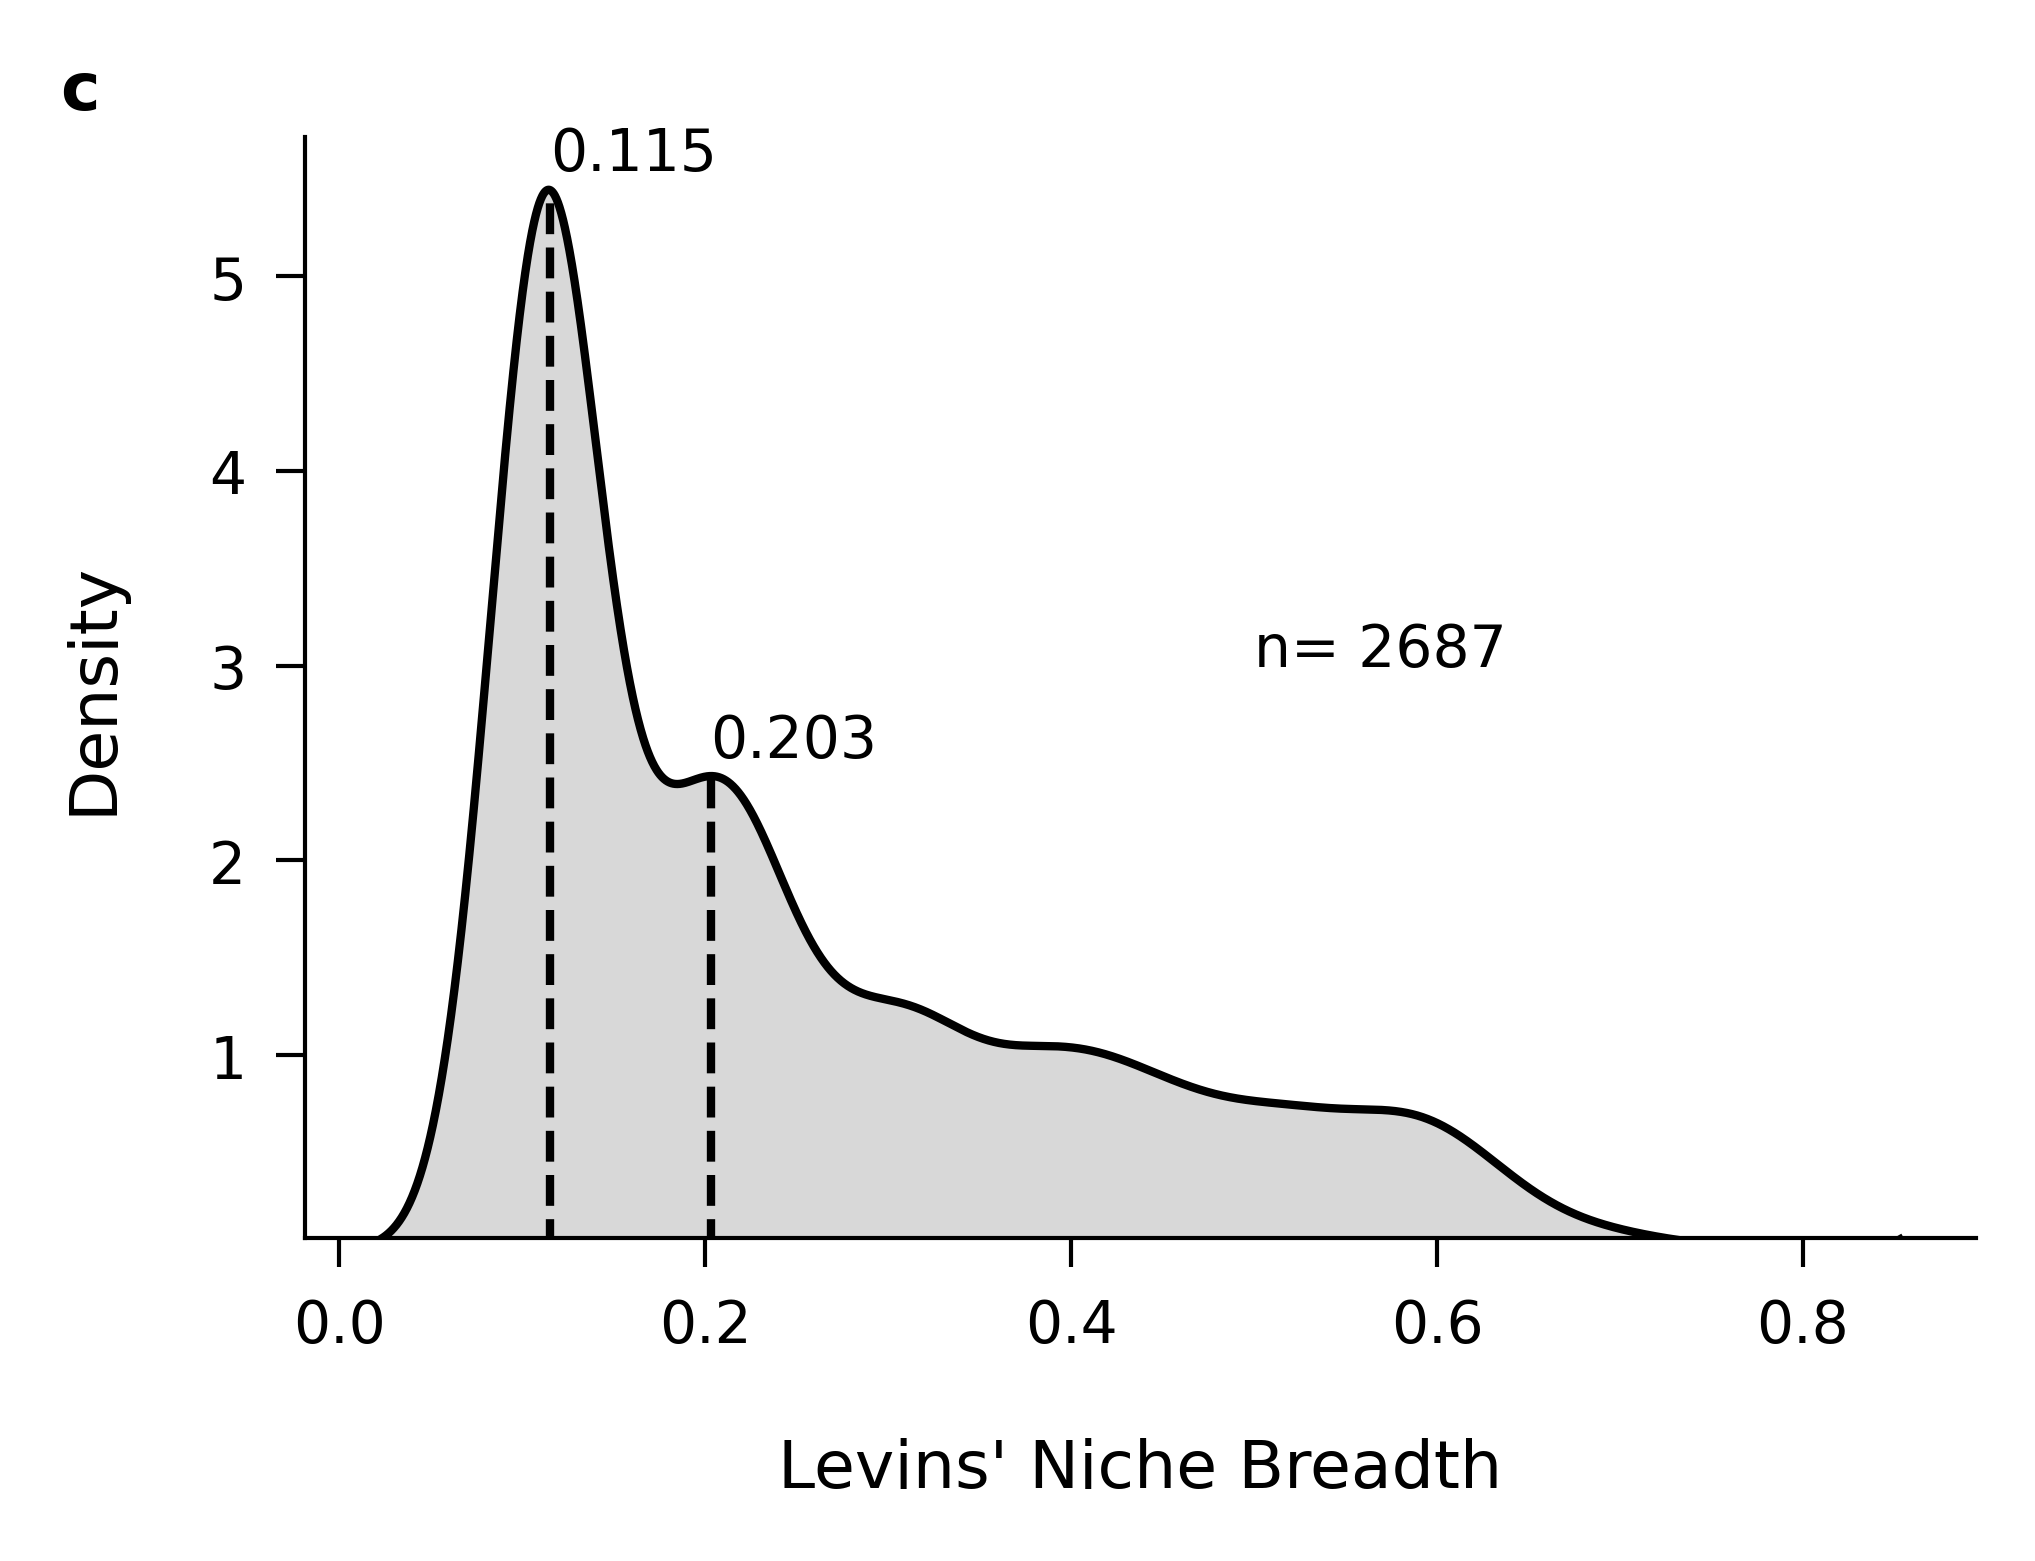

In [8]:
plt.style.use("../nature.mplstyle")

# Set up figure
p = plt.figure(figsize= (3.4,2.5), dpi= 600)

# Perform Kernel Density Estimation
kde= sm.nonparametric.KDEUnivariate(niche_breadth['Bn'])
kde.fit(bw= 'silverman')

# Plot
plt.plot(kde.support, kde.density, color= 'black', linewidth= 1)
plt.fill(kde.support, kde.density, color= 'grey', alpha= 0.3, linewidth= 0)

# Add markers for the modes
## get estimate modes from R 'modes' variable
modes = ro.r['modes']
## add vertical line highlighting each mode
for mode in modes:
    density = kde.evaluate(mode)[0]
    plt.vlines(mode, color= 'black', linewidth= 1, linestyle= '--', ymin= 0, ymax= density)
    plt.text(x= mode, y= density + 0.1, s= str(np.round(mode,3)))

# Add some annotation
plt.text(x=0.5,y= 3, s= f"n= {len(niche_breadth)}")

# Tidy up
## Axis limits
plt.ylim(0.06)

## Axis labels
plt.xlabel("Levins' Niche Breadth", labelpad= 10)
plt.ylabel("Density", labelpad= 10)

## Layout
sns.despine()
p.text(x= 0.03, y= 0.97, s= 'c', weight= 'bold', fontsize= 8)
plt.tight_layout()

# Save to file
plt.savefig("../Figures/Niche_breadth/StageOneActive_NicheBreadth.svg")

## Relative Abundance by Niche Breadth

### Import and format data

In [5]:
# Load niche breadth data
niche_breadth = pd.read_csv("../Datasets/Niche_breadth/StageOneActive_NicheBreadth.csv", index_col= 0).reset_index(names= 'ASV_ID')

# Import stage 2 active data in long format
s2_active = pd.read_csv("../Datasets/Relative_abundance/StageTwoActive_RA_long.csv")

# Merge with metadata
s2_active = pd.merge(left= s2_active, right= sample_data, how= 'left', on= 'Sample')

# Merge with niche breadth data
s2_active = pd.merge(left= s2_active, right= niche_breadth[['ASV_ID','Bn']], how= 'left', on= 'ASV_ID')

# Remove ASVs with NaN niche breadth data
s2_active = s2_active.dropna(axis= 0, subset= 'Bn')



plot_data = s2_active.copy()


# Renormalise the data to sum to 1 in each sample to account for loss of ASVs with no niche breadth data
renormalise = plot_data.groupby('Sample').sum(numeric_only= True).copy()
renormalise = pd.DataFrame((1 / renormalise['Count'])).reset_index()
renormalise.columns = ['Sample','renormalise']
plot_data = pd.merge(left= plot_data, right= renormalise, how= 'left', on= 'Sample')
plot_data['Count'] = plot_data['Count'] * plot_data['renormalise']


# Divide counts by 3 to account for triplicate data (values from triplicates sum to 1)
plot_data['Count'] = plot_data['Count'].apply(lambda value: value/3 if value > 0 else value)

# Select columns of interest
plot_data = plot_data[['Count','Scale of fluctuation','Bn']]

### Round values of Levins' niche breadth

In [6]:
# Round values of Levin's niche breadth
plot_data['Bn'] = plot_data['Bn'].apply(lambda value: np.round(value, decimals= 2))

### Produce barplot

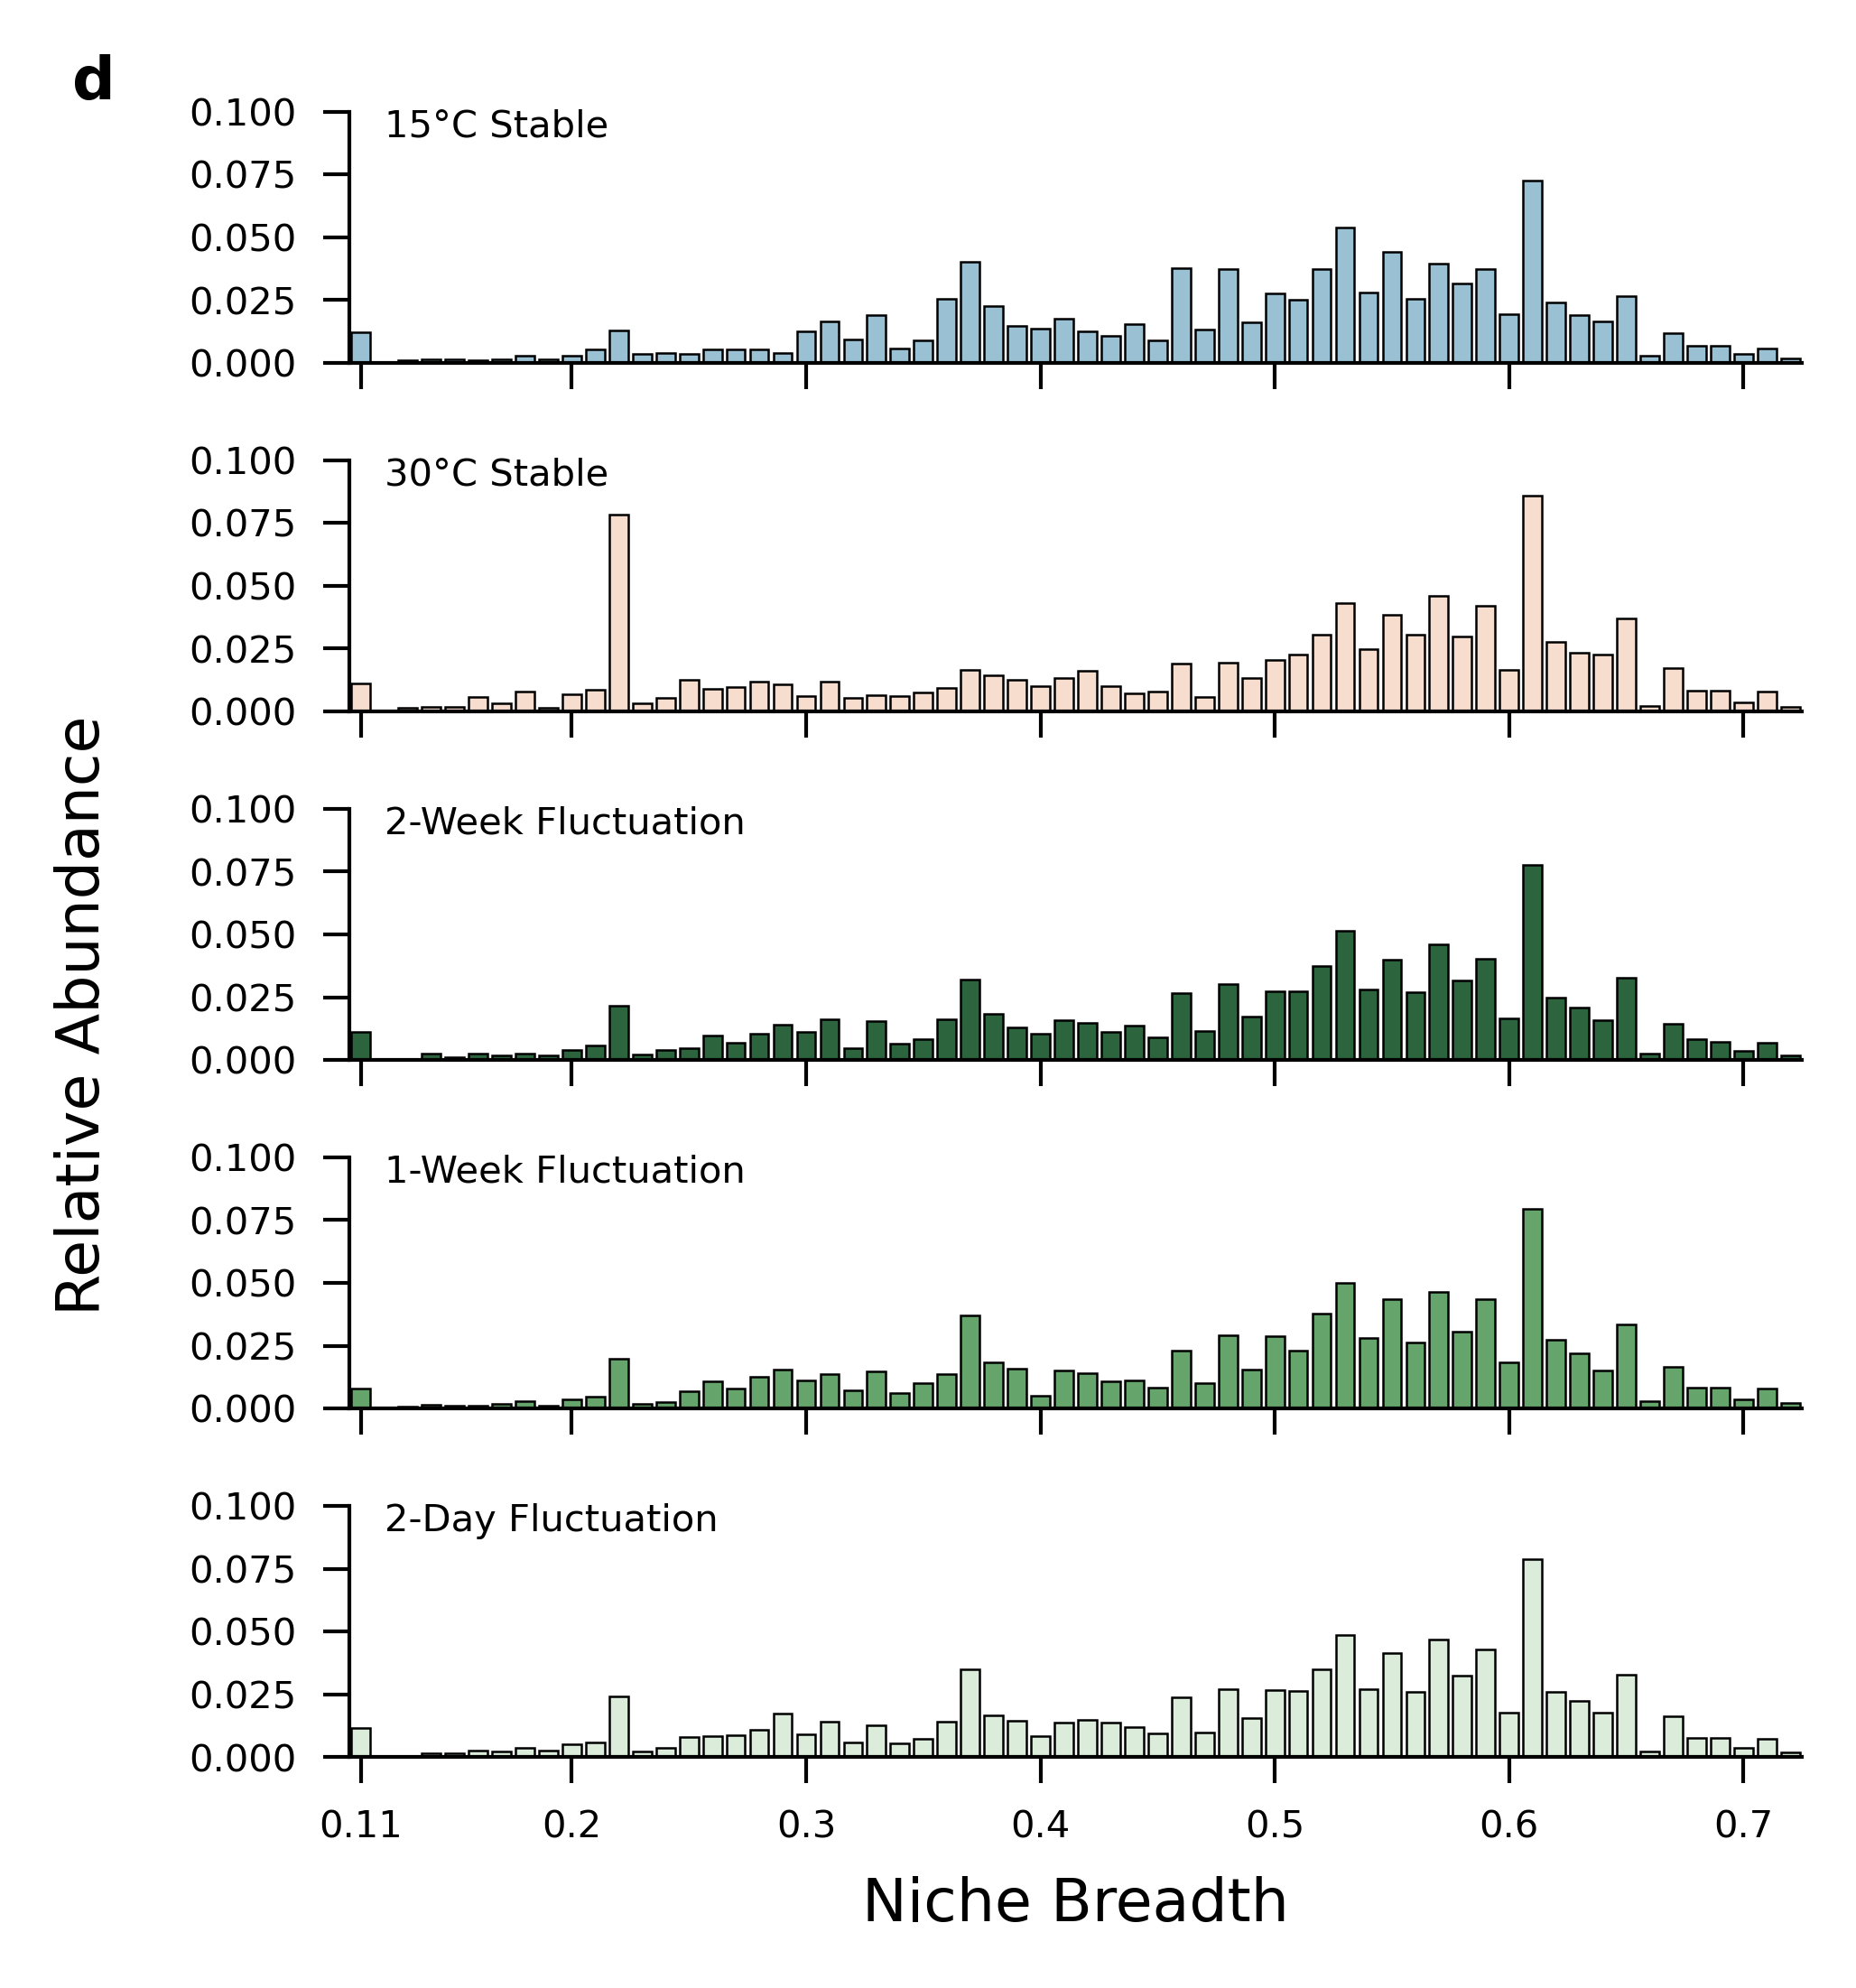

In [9]:
plt.style.use("../nature.mplstyle")

fig, axes = plt.subplots(nrows=5, ncols= 1, figsize= (3.4,3.6), dpi= 600, sharex= True, sharey= True)


# create order for scales of fluctuation
order = ['lowT','highT','2Weeks','1Week','2Days']
labels = ['15°C Stable','30°C Stable', '2-Week Fluctuation','1-Week Fluctuation', '2-Day Fluctuation']
colours = ['#90c4dd','#fddbc7','#216E39','#5AAE61','#D8EFD8']

for i,treatment in enumerate(order):
    # Subset data to treatment of interest
    d = plot_data.groupby(['Scale of fluctuation', 'Bn']).sum().loc[treatment].copy()
    d.reset_index(inplace= True)
    # Make lineplot
    p = sns.barplot(d, x= 'Bn', y= 'Count', ax= axes[i], color= colours[i], edgecolor= 'k', linewidth= 0.3)
    
    # Tidy up
    fs = 5
    p.set_yticks(ticks= [0,0.025, 0.05, 0.075, 0.1])
    p.set_xticks(ticks= [0,9,19,29,39,49,59], minor= False)
    p.set_ylabel('')
    p.set_xlabel('')
    p.tick_params(axis= 'both', labelsize= fs)
    if i == len(order)-1:
        p.set_xlabel('Niche Breadth', fontsize= 8)
    p.text(x= 1, y= 0.09, s= labels[i], fontsize= fs)

# Tidy up
sns.despine()
fig.supylabel('Relative Abundance', fontsize= 8)
fig.tight_layout()

# Add panel letter
fig.text(x= 0.03, y= 0.97, s= 'd', weight= 'bold', fontsize= 8)

# Export data to file
plot_data.groupby(['Scale of fluctuation', 'Bn']).sum().to_csv(
    "../Datasets/Niche_breadth/binned_niche_breadth_abundance.csv")

# Save figure to file
fig.savefig("../Figures/Niche_breadth/Abundance_by_niche_breath_and_fluctuation.svg")

#### Specialist taxa abundance

In [12]:
specialist_abundance = plot_data.groupby(['Scale of fluctuation','Bn']).sum(numeric_only=True).query('Bn == 0.22')
specialist_abundance['Fold difference'] = specialist_abundance['Count'].max() / specialist_abundance['Count']
specialist_abundance

,,Count,Fold difference
Scale of fluctuation,Bn,,
1Week,0.22,0.019949,3.934220
2Days,0.22,0.024271,3.233717
2Weeks,0.22,0.021673,3.621402
highT,0.22,0.078485,1.000000
lowT,0.22,0.012826,6.119126


#### Intermediate taxa abundance

In [13]:
intermediate_abundance = plot_data.groupby(['Scale of fluctuation','Bn']).sum(numeric_only=True).query('Bn == 0.37')
intermediate_abundance['Fold difference'] = intermediate_abundance['Count'].max() / intermediate_abundance['Count']
intermediate_abundance

,,Count,Fold difference
Scale of fluctuation,Bn,,
1Week,0.37,0.037239,1.081103
2Days,0.37,0.034882,1.154165
2Weeks,0.37,0.032060,1.255744
highT,0.37,0.016481,2.442747
lowT,0.37,0.040259,1.000000


#### Generalist taxa abundance

In [14]:
generalist_abundance = plot_data.groupby(['Scale of fluctuation','Bn']).sum(numeric_only=True).query('Bn == 0.61')
generalist_abundance['Fold difference'] = generalist_abundance['Count'].max() / generalist_abundance['Count']
generalist_abundance

,,Count,Fold difference
Scale of fluctuation,Bn,,
1Week,0.61,0.079452,1.080744
2Days,0.61,0.078635,1.091972
2Weeks,0.61,0.077681,1.105388
highT,0.61,0.085868,1.000000
lowT,0.61,0.072676,1.181516
